In [6]:
import pandas as pd
from data_cleaning import missing_strategy
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns
import itertools
from data_cleaning import outlier_strategy


In [ ]:
df0 = pd.read_csv("data/inner_close_sec.csv")
# df0 = missing_strategy(df0,
#                       default_missing_strategy="delete",
#                       except_replace_0=[],
#                       except_replace_mean=[],
#                       except_delete=[])
# all_sec_concat = pd.read_csv("data/all_sec_concat.csv")
# merged_df = all_sec_concat.merge(
#     df0,
#     how="inner",
#     on=["issuer.tradingSymbol", "transactionDate"]
# )
# merged_df.to_csv("data/inner_close_sec.csv")

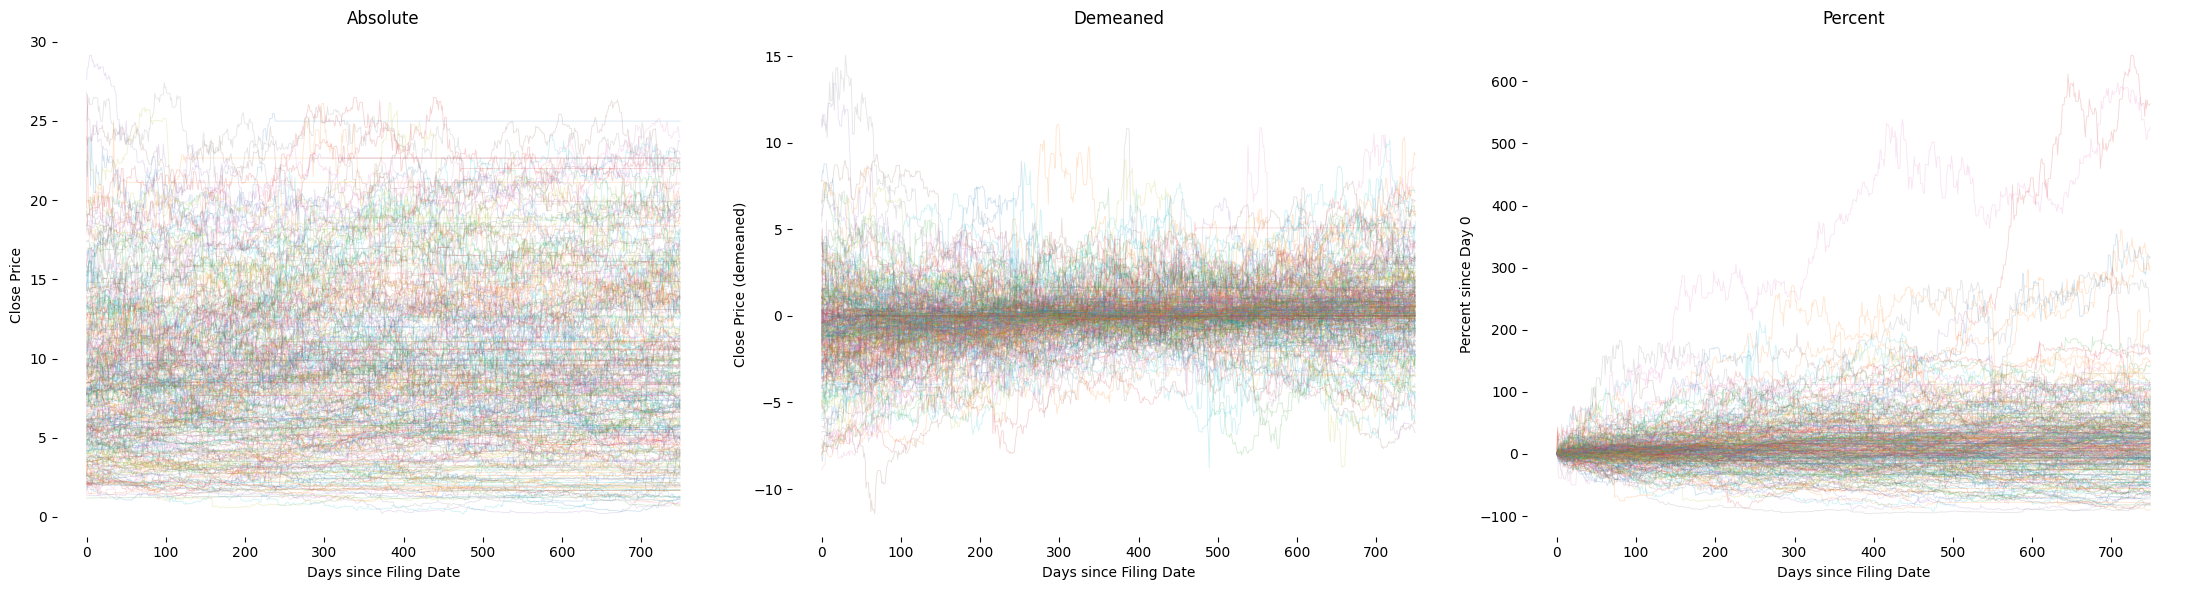

In [ ]:
# remove upper outliers
for num in range(750):
    q75, q25 = np.quantile(df[f'{num}'], [0.75, 0.25])
    iqr = q75 - q25
    df = df[df[f'{num}'] <= q75 + 1.5 * iqr]

day_cols = [str(i) for i in range(750)]

# data is to large, plot only a n=300 sample
sample = df.sample(n=300, random_state=69)

# with matrix or else warning
abs_mat = sample[day_cols].to_numpy(dtype=float)

# calculate demeaned values
row_mean = np.nanmean(abs_mat, axis=1, keepdims=True)
demean_mat = abs_mat - row_mean

# calculate percentage since day 0
ref = sample[day_cols[0]].to_numpy(dtype=float)[:, None]
ref = np.where(ref == 0, np.nan, ref)
percent_mat = ((abs_mat - ref) / ref)*100

x = np.arange(750)

# plot absolute, demeaned and percentage in one pic
fig, axs = plt.subplots(1, 3, figsize=(22, 6), sharex=True)

axs[0].plot(x, abs_mat.T, linewidth=0.6, alpha=0.2)
axs[0].set_title('Absolute')
axs[0].set_xlabel('Days since Filing Date')
axs[0].set_ylabel('Close Price')

axs[1].plot(x, demean_mat.T, linewidth=0.6, alpha=0.2)
axs[1].set_title('Demeaned')
axs[1].set_xlabel('Days since Filing Date')
axs[1].set_ylabel('Close Price (demeaned)')

axs[2].plot(x, percent_mat.T, linewidth=0.6, alpha=0.2)
axs[2].set_title('Percent')
axs[2].set_xlabel('Days since Filing Date')
axs[2].set_ylabel('Percent since Day 0')

for ax in axs:
    for spine in ax.spines.values():
        spine.set_visible(False)

plt.tight_layout()
plt.savefig('exports/descriptive_random_state_69.png', dpi=500)
plt.show()

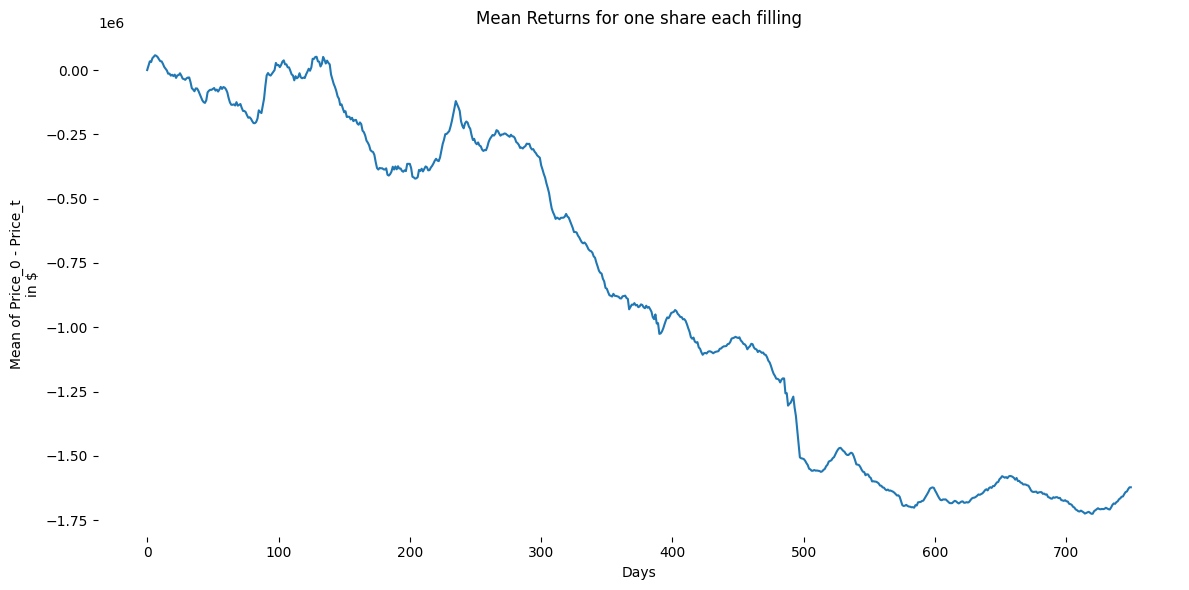

In [20]:
df = df0
# Mean Returns for one share each filling
x_0 = df['0'].to_numpy()[:, None]
day_cols = [str(i) for i in range(750)]
Xt = df[day_cols].to_numpy()
return_matrix = Xt - x_0
return_df = pd.DataFrame(return_matrix)
mean_return = return_df.mean()

fig, ax = plt.subplots(1, 1, figsize=(12, 6))

ax.plot(mean_return)
ax.set_title('Mean Returns for one share each filling')
ax.set_xlabel('Days')
ax.set_ylabel('Mean of Price_0 - Price_t\nin $')

for s in ax.spines.values():
    s.set_visible(False)

plt.tight_layout()
plt.savefig('exports/Mean_return.png', dpi=500)
plt.show()

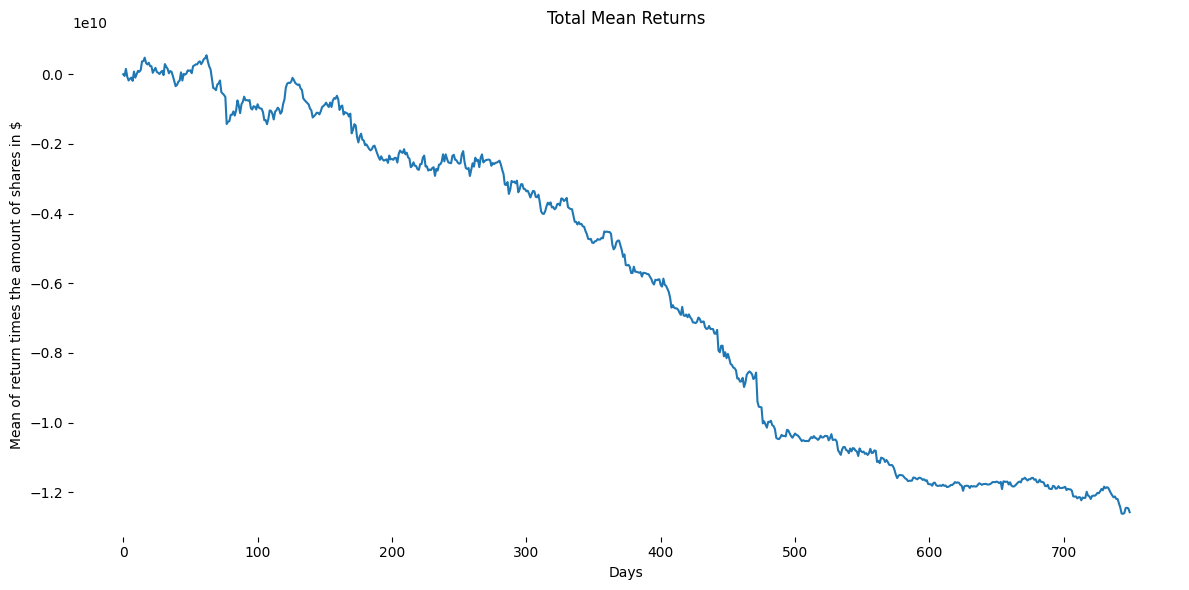

In [21]:

# Total Mean Returns: actual return with amount of shares
n = merged_df['amounts.shares'].to_numpy()[:, None]
x_0 = merged_df['0'].to_numpy()[:, None]
day_cols = [str(i) for i in range(750)]
Xt = merged_df[day_cols].to_numpy()
return_matrix = (Xt - x_0)*n
return_df = pd.DataFrame(return_matrix)
mean_return = return_df.mean()

fig, ax = plt.subplots(1, 1, figsize=(12, 6))

ax.plot(mean_return)
ax.set_title('Total Mean Returns')
ax.set_xlabel('Days')
ax.set_ylabel('Mean of return times the amount of shares in $')

for s in ax.spines.values():
    s.set_visible(False)

plt.tight_layout()
plt.savefig('exports/Mean_of_return_times_the_amount_of_shares.png', dpi=500)
plt.show()

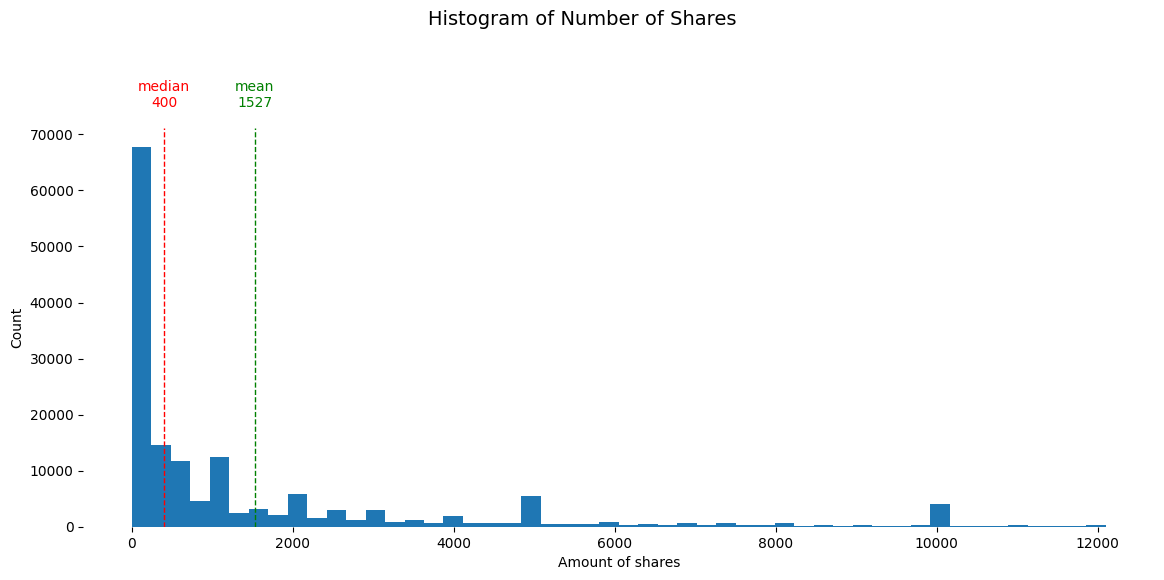

In [7]:
from data_cleaning import outlier_strategy
# Histogram of shares
keep_cols = [c for c in df0.columns if not (str(c).isdigit() and 0 <= int(c) <= 750)]

df = df0.loc[:, keep_cols]
df = \
    outlier_strategy(df,
                     default_outlier_strategy="delete",
                     except_replace_0=[],
                     except_replace_mean=[],
                     except_delete=[],
                     ignore=[])

fig, ax = plt.subplots(1, 1, figsize=(12, 6))
fig.suptitle("Histogram of Number of Shares", fontsize=14)
ax.hist(df['amounts.shares'], bins=50)
ax.set_xlabel('Amount of shares')
ax.set_ylabel('Count')

median = df['amounts.shares'].median()

for s in ax.spines.values():
    s.set_visible(False)
ax.axvline(median, linestyle="--", lw=1, c="red")
ax.text(median,
        ax.get_ylim()[1]*+1.12,
        f"median\n{median:.0f}",
        va="top",
        ha="center",
        color="red")

mean = df['amounts.shares'].mean()

for s in ax.spines.values():
    s.set_visible(False)
ax.axvline(mean, linestyle="--", lw=1, c="green")
ax.text(mean,
        ax.get_ylim()[1]*+1.12,
        f"mean\n{mean:.0f}",
        va="top",
        ha="center",
        color="green")

plt.tight_layout(pad=2.0, w_pad=1.0, h_pad=2.0)
plt.savefig('exports/Histogram_of_Number_of_Shares.png', dpi=500)
plt.show()

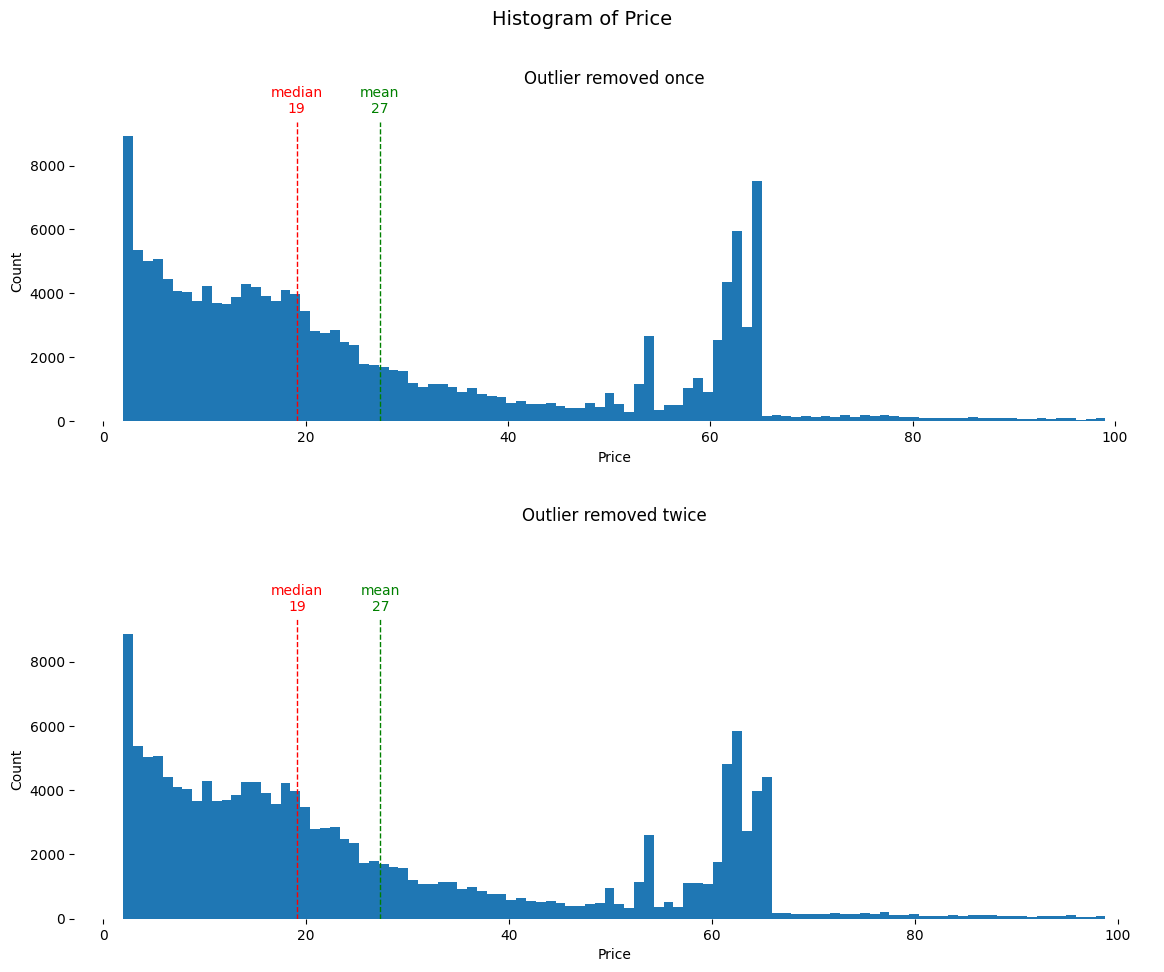

In [9]:
# Histogram of Price
fig, ax = plt.subplots(2, 1, figsize=(12, 10))
fig.suptitle("Histogram of Price", fontsize=14)

ax[0].hist(df['amounts.pricePerShare'], bins=100)
ax[0].set_title('Outlier removed once', y=1.1)
ax[0].set_xlabel('Price')
ax[0].set_ylabel('Count')

# remove upper outliers in amounts.pricePerShare for better look
df_copy = df.copy()
q75, q25 = np.quantile(df_copy['amounts.pricePerShare'], [0.75, 0.25])
iqr = q75 - q25
df_copy = df_copy[df_copy['amounts.pricePerShare'] <= q75 + 1.5 * iqr]

ax[1].hist(df_copy['amounts.pricePerShare'], bins=100)
ax[1].set_title('Outlier removed twice', y=1.3)
ax[1].set_xlabel('Price')
ax[1].set_ylabel('Count')

# median / mean per axis with correct df
data_per_axis = {
    0: df['amounts.pricePerShare'],
    1: df_copy['amounts.pricePerShare'],
}

for i in [0, 1]:
    for s in ax[i].spines.values():
        s.set_visible(False)

    median = data_per_axis[i].median()
    mean = data_per_axis[i].mean()

    ax[i].axvline(median, linestyle="--", lw=1, c="red")
    ax[i].text(
        median,
        ax[i].get_ylim()[1] * 1.12,
        f"median\n{median:.0f}",
        va="top",
        ha="center",
        color="red",
        clip_on=False,
    )

    ax[i].axvline(mean, linestyle="--", lw=1, c="green")
    ax[i].text(
        mean,
        ax[i].get_ylim()[1] * 1.12,
        f"mean\n{mean:.0f}",
        va="top",
        ha="center",
        color="green",
        clip_on=False,
    )

plt.tight_layout(pad=2.0, w_pad=1.0, h_pad=2.0)
plt.savefig('exports/Histogram_price.png', dpi=500)
plt.show()


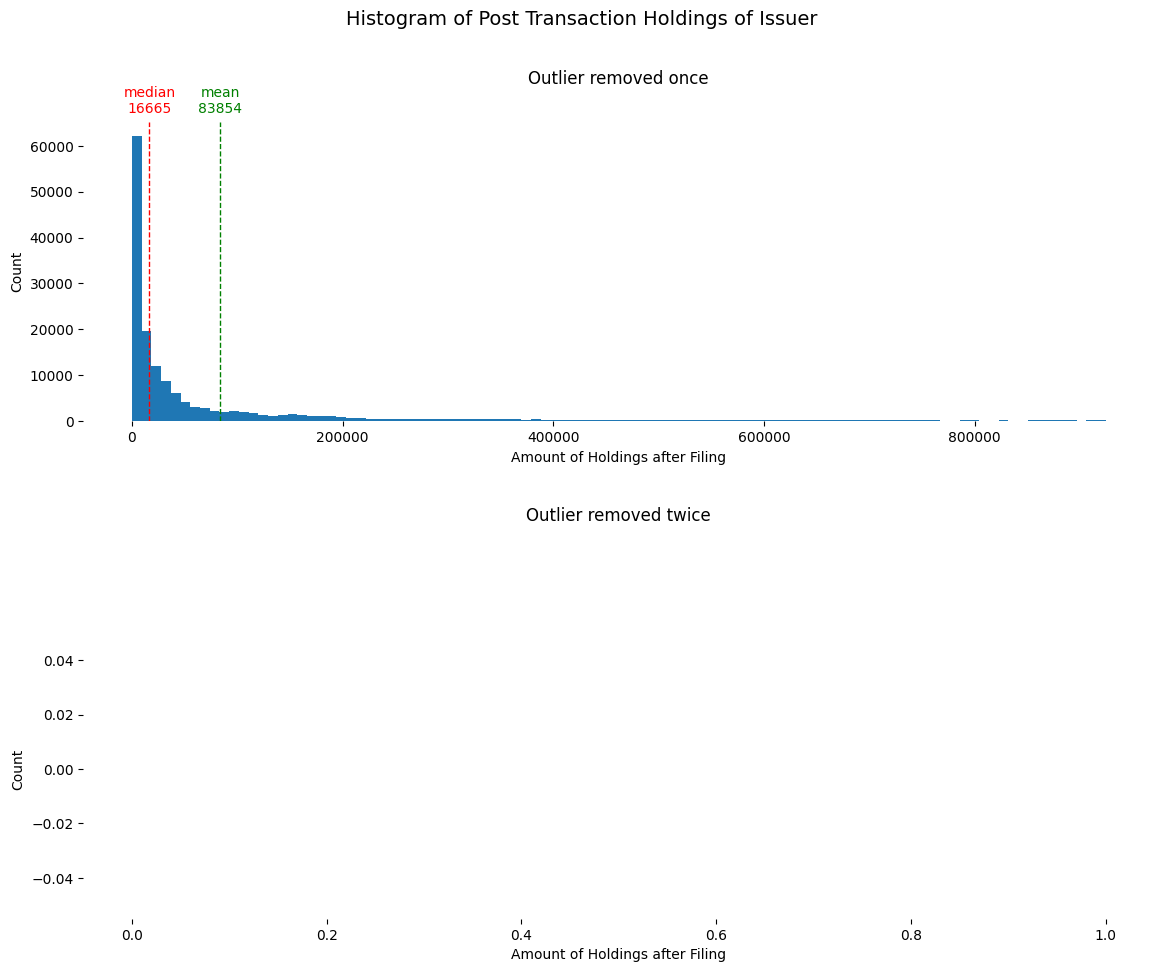

In [10]:

# Histogram of Post Transaction Holdings of Issuer
fig, ax = plt.subplots(2, 1, figsize=(12, 10))
fig.suptitle("Histogram of Post Transaction Holdings of Issuer", fontsize=14)

ax[0].hist(df['postTransactionAmounts.sharesOwnedFollowingTransaction'], bins=100)
ax[0].set_title('Outlier removed once', y=1.1)
ax[0].set_xlabel('Amount of Holdings after Filing')
ax[0].set_ylabel('Count')

# remove upper outliers in postTransactionAmounts.sharesOwnedFollowingTransaction for better look
df_copy = df.copy()
q75, q25 = np.quantile(
    df['postTransactionAmounts.sharesOwnedFollowingTransaction'], [0.75, 0.25]
)
iqr = q75 - q25
df_copy = df_copy[
    df_copy['postTransactionAmounts.sharesOwnedFollowingTransaction'] <= q75 + 1.5 * iqr
]

ax[1].hist(df_copy['postTransactionAmounts.sharesOwnedFollowingTransaction'], bins=100)
ax[1].set_title('Outlier removed twice', y=1.3)
ax[1].set_xlabel('Amount of Holdings after Filing')
ax[1].set_ylabel('Count')

# median / mean per axis with correct df
data_per_axis = {
    0: df['postTransactionAmounts.sharesOwnedFollowingTransaction'],
    1: df_copy['postTransactionAmounts.sharesOwnedFollowingTransaction'],
}

for i in [0, 1]:
    for s in ax[i].spines.values():
        s.set_visible(False)

    median = data_per_axis[i].median()
    mean = data_per_axis[i].mean()

    ax[i].axvline(median, linestyle="--", lw=1, c="red")
    ax[i].text(
        median,
        ax[i].get_ylim()[1] * 1.12,
        f"median\n{median:.0f}",
        va="top",
        ha="center",
        color="red",
        clip_on=False,
    )

    ax[i].axvline(mean, linestyle="--", lw=1, c="green")
    ax[i].text(
        mean,
        ax[i].get_ylim()[1] * 1.12,
        f"mean\n{mean:.0f}",
        va="top",
        ha="center",
        color="green",
        clip_on=False,
    )

plt.tight_layout(pad=2.0, w_pad=1.0, h_pad=2.0)
plt.savefig('exports/Histogram_of_Postransamount.png', dpi=500)
plt.show()


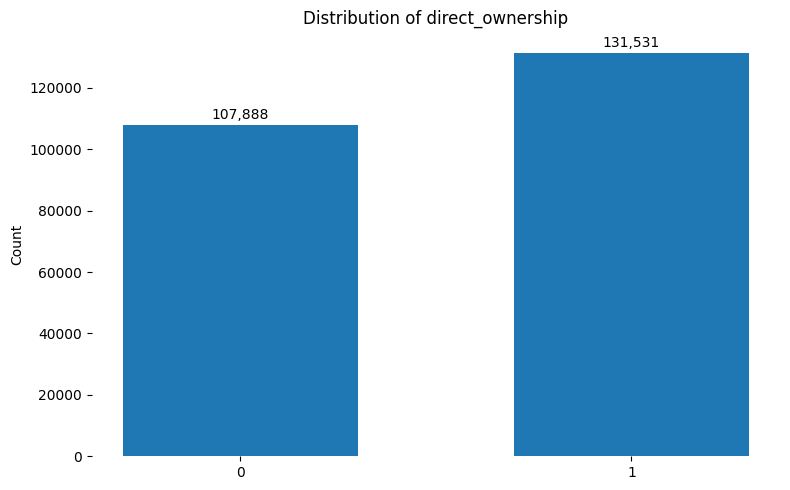

In [13]:
df = pd.read_csv("data/final_final_df.csv")
# Distribution of direct_ownership
ser = df['direct_ownership']
counts = ser.value_counts(dropna=False).sort_index()

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(counts.index.astype(str), counts.values, width=0.6)

ax.bar_label(bars, labels=[f"{v:,}" for v in counts.values], padding=2)
ax.set_ylabel('Count')
ax.set_title('Distribution of direct_ownership')
for s in ax.spines.values():
    s.set_visible(False)
plt.tight_layout()
plt.savefig('exports/ownership.png', dpi=500)
plt.show()

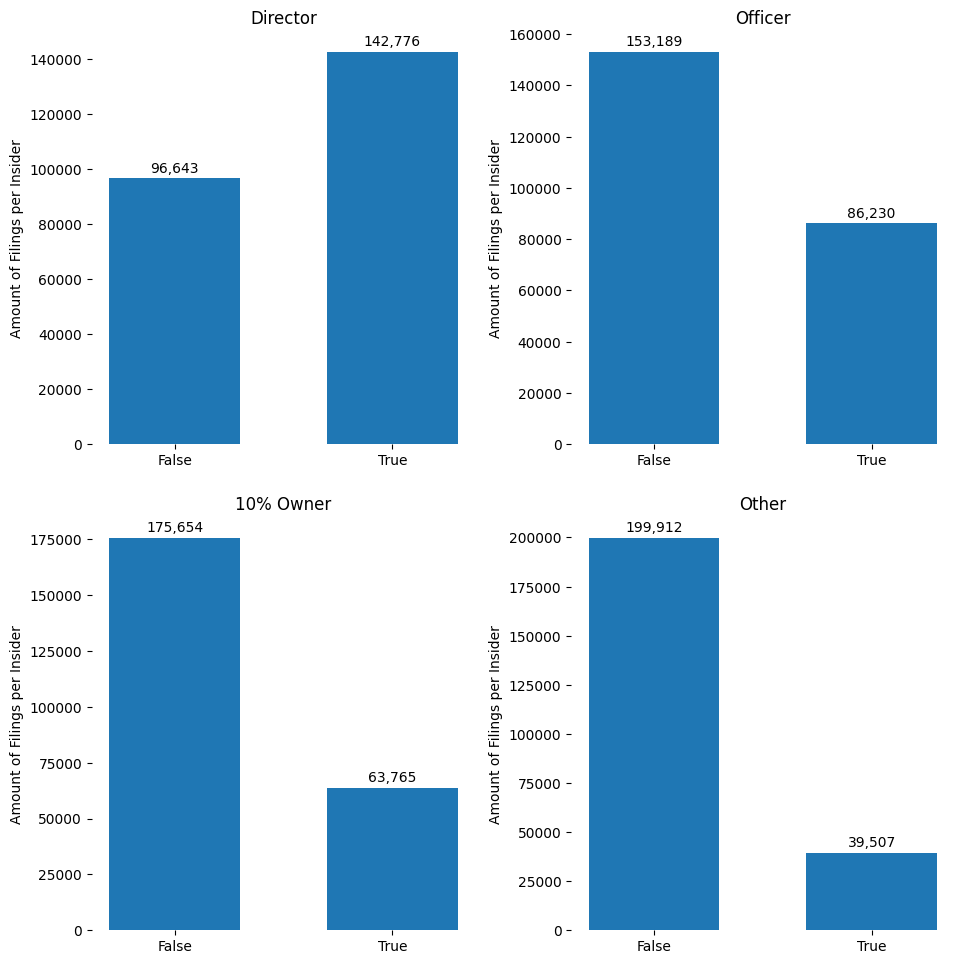

In [14]:

# Distribution of is_direct, officer, 10percent, other
vars = ['reportingOwner.relationship.isDirector',
        'reportingOwner.relationship.isOfficer',
        'reportingOwner.relationship.isTenPercentOwner',
        'reportingOwner.relationship.isOther']

titles = ['Director', 'Officer', '10% Owner', 'Other']

fig, ax = plt.subplots(2, 2, figsize=(10, 10))
axes = ax.ravel()

for i, v in enumerate(vars):
    ser = df[v]
    counts = ser.value_counts(dropna=False).sort_index()

    for s in axes[i].spines.values():
        s.set_visible(False)

    bars = axes[i].bar(counts.index.astype(str), counts.values, width=0.6)
    axes[i].bar_label(bars, labels=[f"{int(val):,}" for val in counts.values], padding=2)
    axes[i].set_ylabel('Amount of Filings per Insider')
    axes[i].set_title(titles[i])

plt.tight_layout(pad=2.0, w_pad=1.0, h_pad=2.0)
plt.savefig('exports/relationship.png', dpi=500)
plt.show()